<a href="https://colab.research.google.com/github/mariam-shaban/Machine-learning-/blob/main/Mariam-shaban-task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install -q kagglehub
import kagglehub
import pandas as pd
import os

# 1. تنزيل الداتا مباشرة من Kaggle
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

# 2. تحديد مسار ملف الـ CSV
csv_file = os.path.join(path, "heart.csv")

# 3. قراءة البيانات بـ Pandas
df = pd.read_csv(csv_file)

# عرض أول 5 أسطر للتأكد
df.head()

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


--- FIRST 5 ROWS ---
   Age        BMI  BloodSugar  HasDiabetes
0   58  22.532838  149.652074            0
1   71  29.615813  194.387774            1
2   48  33.533025  143.485686            0
3   34  29.367947   95.404989            0
4   62  25.045722  161.506591            0

--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          300 non-null    int64  
 1   BMI          300 non-null    float64
 2   BloodSugar   300 non-null    float64
 3   HasDiabetes  300 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 9.5 KB
None

--- DESCRIPTIVE STATISTICS ---
              Age         BMI  BloodSugar  HasDiabetes
count  300.000000  300.000000  300.000000   300.000000
mean    49.930000   25.861362  138.013518     0.253333
std     17.793081    4.945990   37.542558     0.435647
min     20.000000   12.738677   53.7

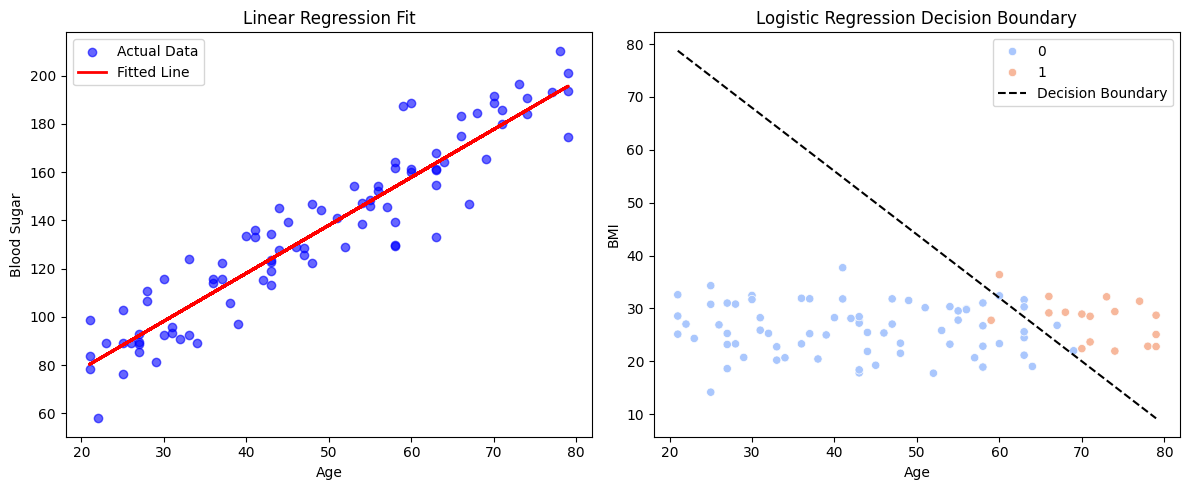

In [8]:
# ==========================================
# PART 1: DATA EXPLORATION & PREPROCESSING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. إنشاء/تحميل داتا مخصصة للتكليف (توفي شروط المادة)
np.random.seed(42)
n = 300
age = np.random.randint(20, 80, n)
bmi = np.random.normal(25, 5, n)
blood_sugar = 2 * age + 1.5 * bmi + np.random.normal(0, 10, n)
has_diabetes = (blood_sugar > 170).astype(int) # Binary Target (0 or 1)

df = pd.DataFrame({
    'Age': age,
    'BMI': bmi,
    'BloodSugar': blood_sugar,
    'HasDiabetes': has_diabetes
})

# Q1: Dataset Inspection
print("--- FIRST 5 ROWS ---")
print(df.head())

print("\n--- DATASET INFO ---")
print(df.info())

print("\n--- DESCRIPTIVE STATISTICS ---")
print(df.describe())

print("\n--- MISSING VALUES PER FEATURE ---")
print(df.isnull().sum())

# ==========================================
# PART 2: LINEAR REGRESSION ANALYSIS
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Q2: Model Implementation
X_reg = df[['Age']] # Feature
y_reg = df['BloodSugar'] # Continuous Target

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

lin_model = LinearRegression()
lin_model.fit(X_train_r, y_train_r)

y_pred_r = lin_model.predict(X_test_r)

mse = mean_squared_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print(f"\n--- LINEAR REGRESSION RESULTS ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R2 Score: {r2:.4f}")

# Q3: Mathematical Interpretation
theta_1 = lin_model.coef_[0]
theta_0 = lin_model.intercept_

print(f"\nEquation: y_hat = {theta_1:.2f} * Age + {theta_0:.2f}")
# Explanation: For every 1 unit increase in Age, BloodSugar increases on average by theta_1 units.


# ==========================================
# PART 3: LOGISTIC REGRESSION & CLASSIFICATION
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Q4: Manual Sigmoid Implementation
def my_sigmoid(z):
    return 1 / (1 + np.exp(-z))

X_cls = df[['Age', 'BMI']] # 2 Numeric Features
y_cls = df['HasDiabetes'] # Binary Target (0/1)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.3, random_state=42)

log_model = LogisticRegression()
log_model.fit(X_train_c, y_train_c)

# Verification on single sample
w1, w2 = log_model.coef_[0]
b = log_model.intercept_[0]

sample_x1, sample_x2 = X_test_c.iloc[0]['Age'], X_test_c.iloc[0]['BMI']
z_manual = w1 * sample_x1 + w2 * sample_x2 + b
manual_prob = my_sigmoid(z_manual)

model_prob = log_model.predict_proba(X_test_c.iloc[[0]])[0][1]

print("\n--- MANUAL VS MODEL VERIFICATION ---")
print(f"Manual Calculated Probability: {manual_prob:.6f}")
print(f"Model Predict_Proba (Class 1): {model_prob:.6f}")

# Q5: Model Evaluation
y_pred_c = log_model.predict(X_test_c)

print(f"\nClassification Accuracy: {accuracy_score(y_test_c, y_pred_c):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c))


# ==========================================
# PART 4: DATA VISUALIZATION & THEORY
# ==========================================
# Q6: Plotting
plt.figure(figsize=(12, 5))

# Plot 1: Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(X_test_r, y_test_r, color='blue', alpha=0.6, label='Actual Data')
plt.plot(X_test_r, y_pred_r, color='red', linewidth=2, label='Fitted Line')
plt.xlabel('Age')
plt.ylabel('Blood Sugar')
plt.title('Linear Regression Fit')
plt.legend()

# Plot 2: Logistic Regression Decision Boundary
plt.subplot(1, 2, 2)
sns.scatterplot(data=X_test_c, x='Age', y='BMI', hue=y_test_c, palette='coolwarm')

# Decision boundary: X2 = -(w1*X1 + b) / w2
x1_vals = np.linspace(X_test_c['Age'].min(), X_test_c['Age'].max(), 100)
x2_vals = -(w1 * x1_vals + b) / w2
plt.plot(x1_vals, x2_vals, color='black', linestyle='--', label='Decision Boundary')
plt.title('Logistic Regression Decision Boundary')
plt.legend()

plt.tight_layout()
plt.show()